# Online Regime

In [60]:
#Import packages 

import math
import torch
import matplotlib.pyplot as plt
import numpy as np

In [74]:
path = 'experimentos_resultados/fixed/0.9_64_10000_'

nexp = 3

t_step = 10000



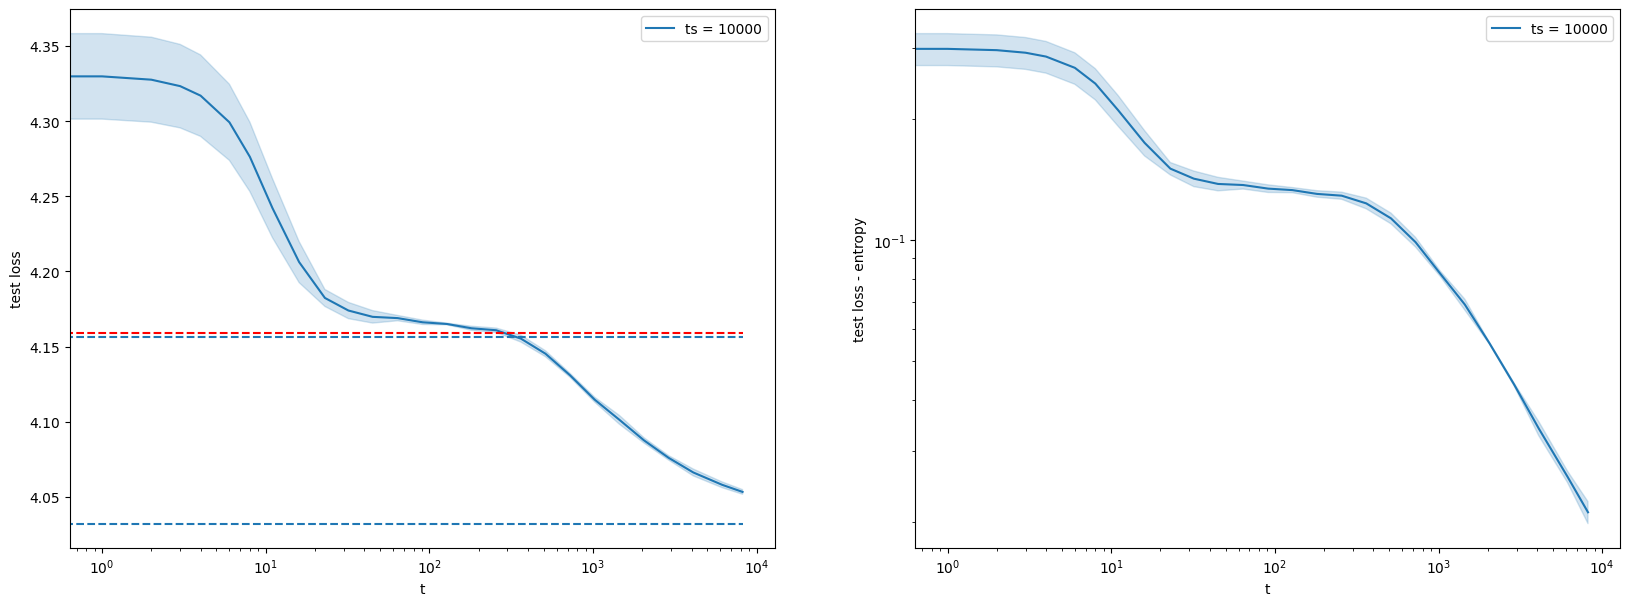

In [75]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [77]:
len(dyn)

27

In [79]:
path = 'experimentos_resultados/fixed/0.9_6435000'

nexp = 3

t_step = 35000


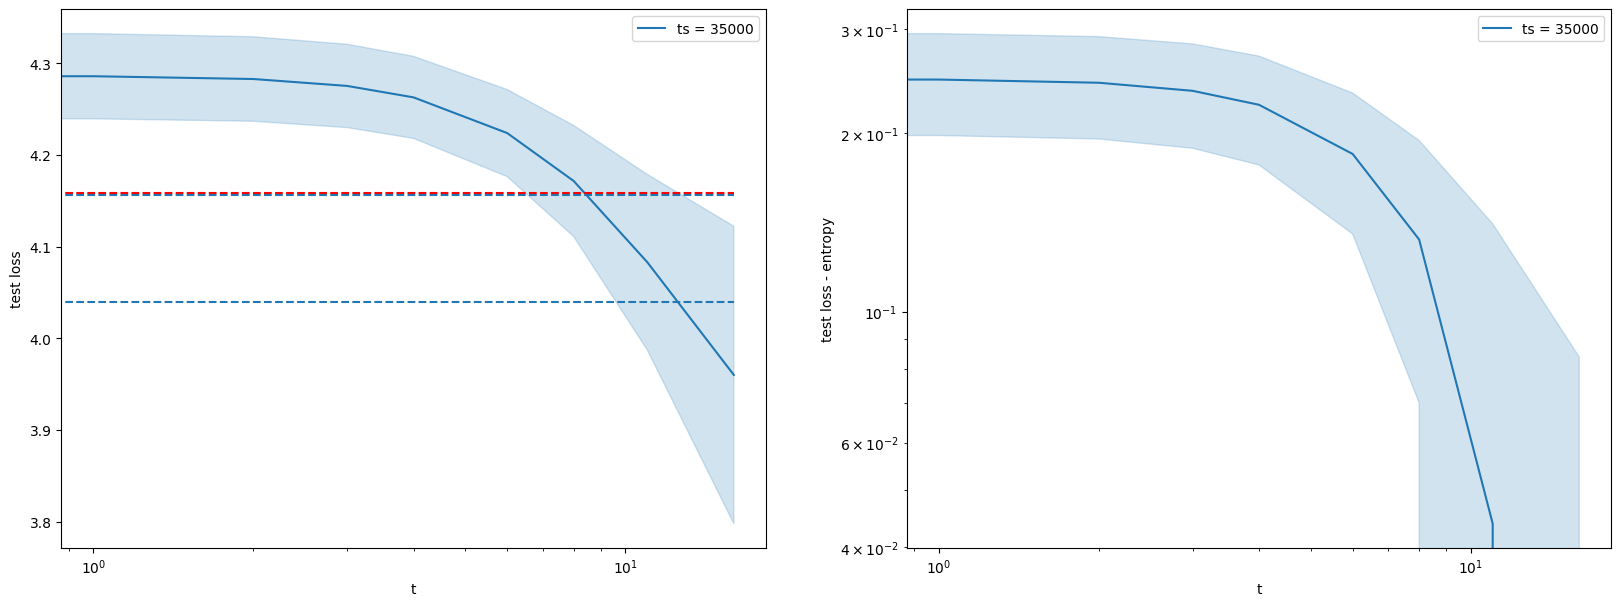

In [80]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['trainloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [ ]:
dyn

[{'t': 0,
  'testloss': 4.328106878325343,
  'testacc': 0.016845703125,
  'trainloss': 4.227923089807684,
  'trainacc': 0.045454545454545456},
 {'t': 1,
  'testloss': 4.328106878325343,
  'testacc': 0.016845703125,
  'trainloss': 4.227923089807684,
  'trainacc': 0.045454545454545456},
 {'t': 2,
  'testloss': 4.328380573540926,
  'testacc': 0.016845703125,
  'trainloss': 4.224820743907582,
  'trainacc': 0.045454545454545456},
 {'t': 3,
  'testloss': 4.328257279470563,
  'testacc': 0.01694488525390625,
  'trainloss': 4.216482379219749,
  'trainacc': 0.045454545454545456},
 {'t': 4,
  'testloss': 4.32791012711823,
  'testacc': 0.01694488525390625,
  'trainloss': 4.202289581298828,
  'trainacc': 0.045454545454545456},
 {'t': 6,
  'testloss': 4.327027764171362,
  'testacc': 0.01735687255859375,
  'trainloss': 4.157026681033048,
  'trainacc': 0.06818181818181818},
 {'t': 8,
  'testloss': 4.328068660572171,
  'testacc': 0.017230987548828125,
  'trainloss': 4.095280820673162,
  'trainacc': 0.0

In [81]:
path = 'experimentos_resultados/fixed/trust/0.8_v16_30000_32_'

nexp = 3

t_step = 35000


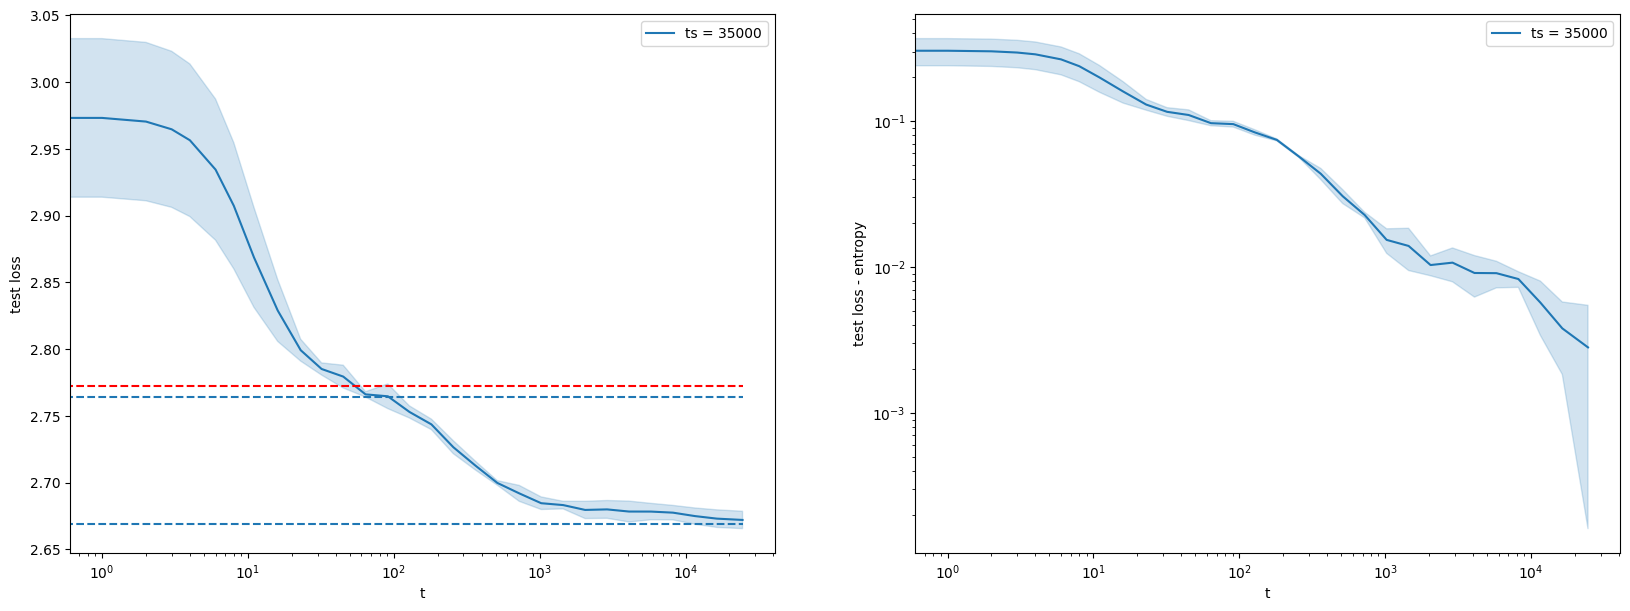

In [84]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(16) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

# Pruebas variando V y Beta 

## Prueba 1 

Parametros;

Pasos: 30,000

Vocab = 16

Beta = 0.5

In [87]:
path = 'experimentos_resultados/fixed/beta_v/0.5_v16_30000_32_'

nexp = 8

t_step = 30000


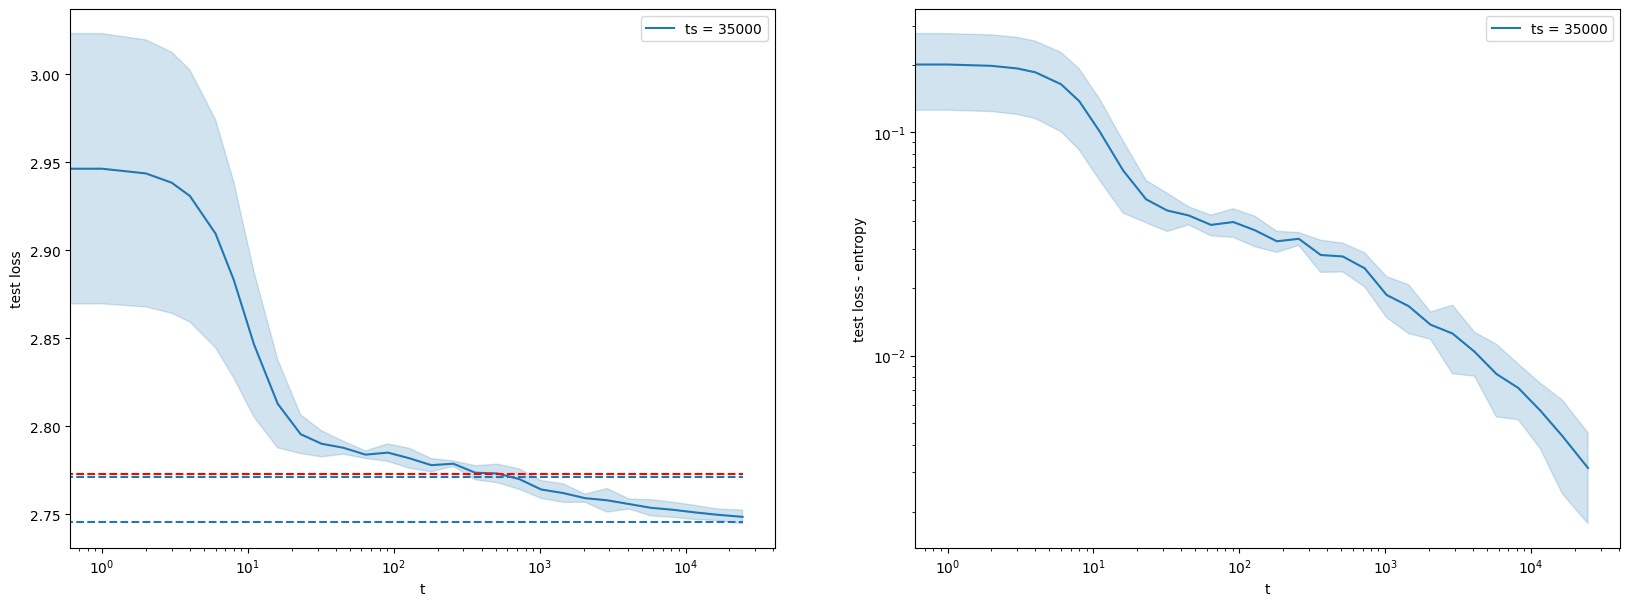

In [86]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(16) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 2 

Parametros;

Pasos: 30,000

Vocab= 32

Beta= 0.5

In [88]:
path = 'experimentos_resultados/fixed/beta_v/0.5_v32_30000_32_'

nexp = 8

t_step = 30000

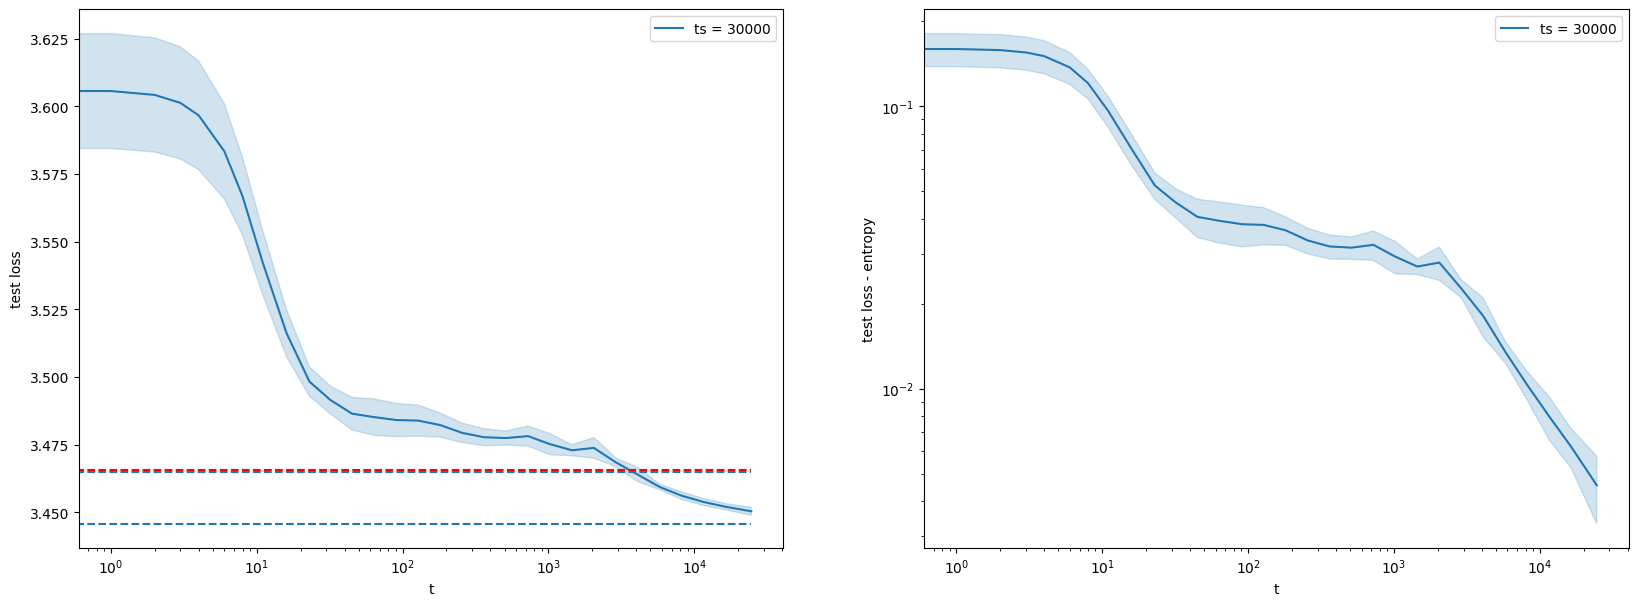

In [92]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(32) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 3 

Parametros;

Pasos: 30,000

Vocab= 64

Beta= 0.5

In [93]:
path = 'experimentos_resultados/fixed/beta_v/0.5_v64_30000_32_'

nexp = 8

t_step = 30000

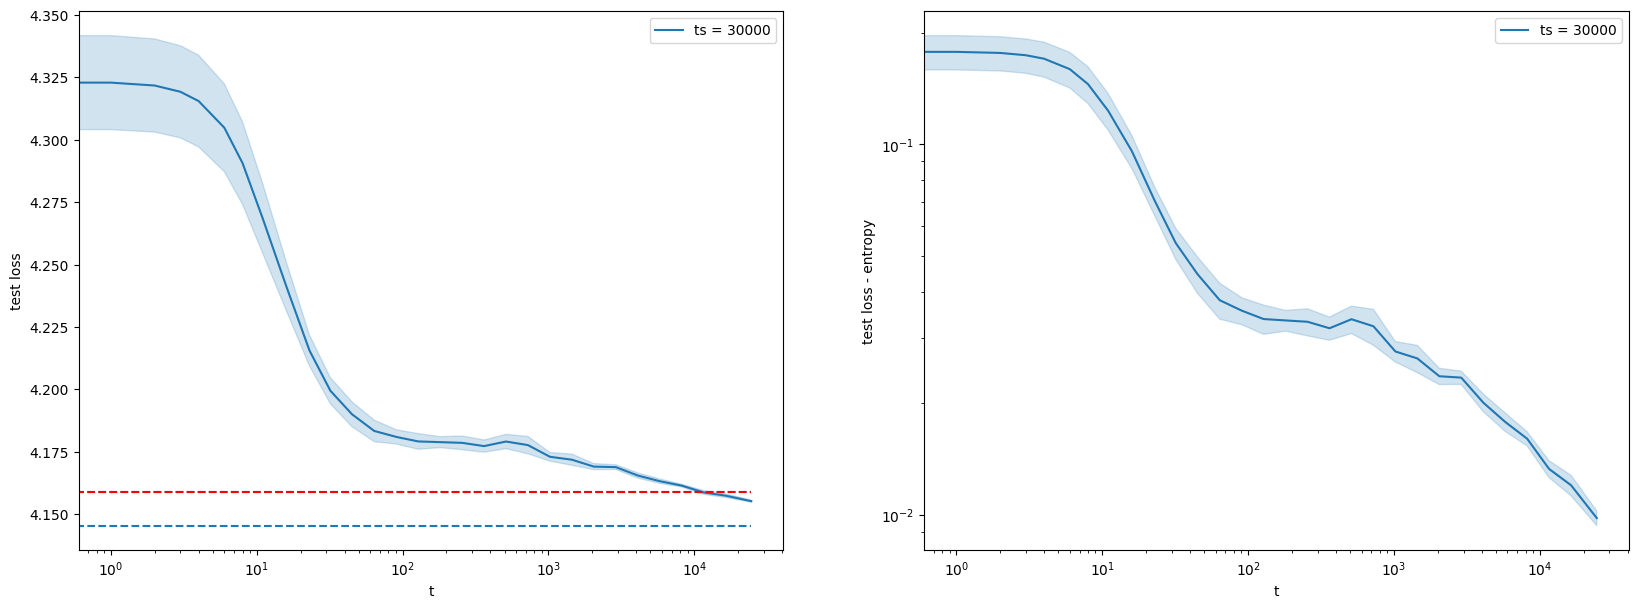

In [95]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 4 

Parametros;

Pasos: 30,000

Vocab= 16

Beta= 0.8

In [96]:
path = 'experimentos_resultados/fixed/beta_v/0.8_v16_30000_32_'

nexp = 8

t_step = 30000


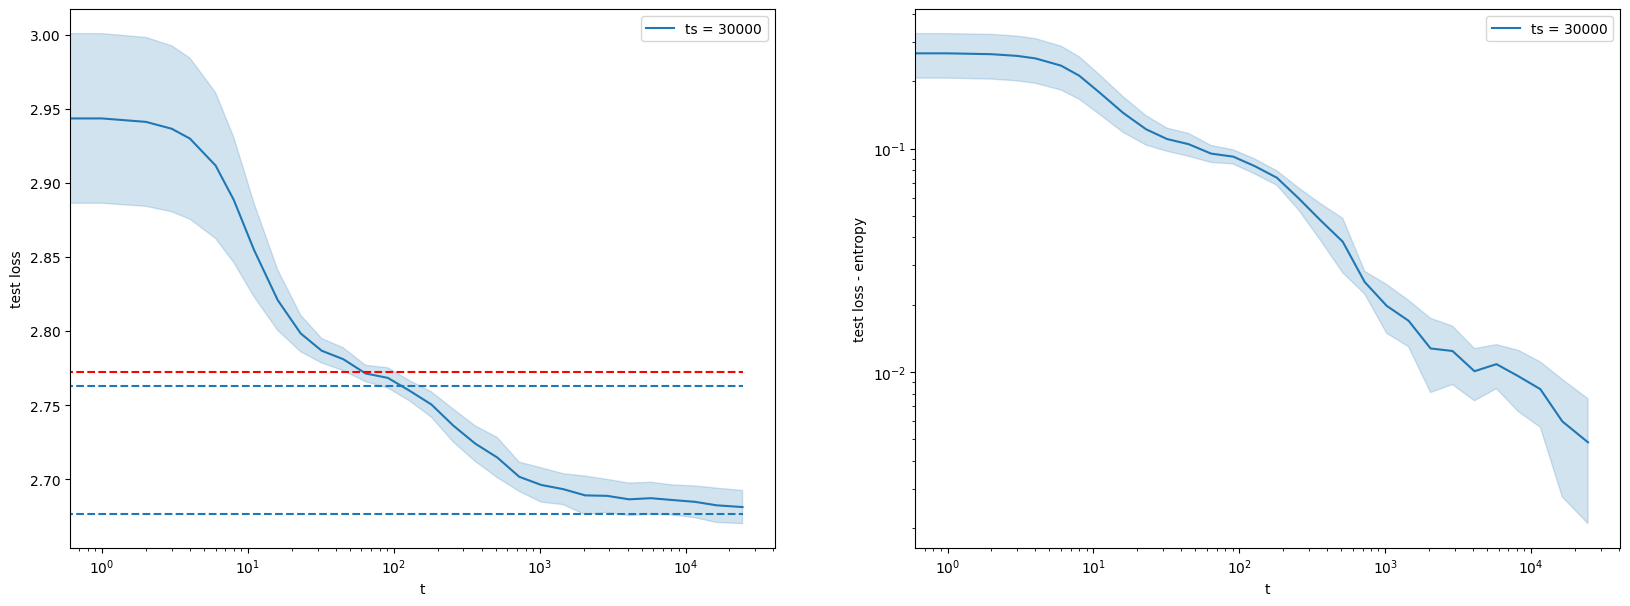

In [97]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(16) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 5 

Parametros;

Pasos: 30,000

Vocab= 32

Beta= 0.8

In [98]:
path = 'experimentos_resultados/fixed/beta_v/0.8_v32_30000_32_'

nexp = 8

t_step = 30000


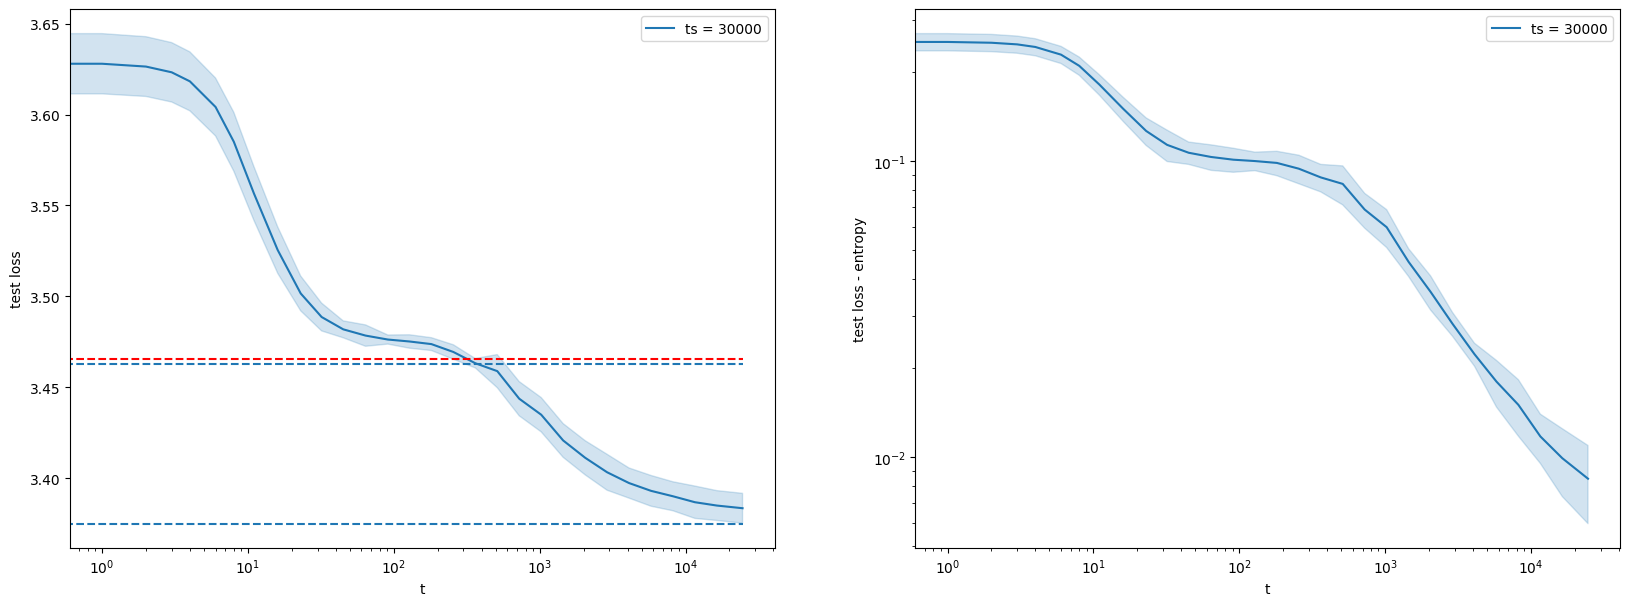

In [100]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(32) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 6 

Parametros

Pasos 

Vocab

Beta 

In [101]:
path = 'experimentos_resultados/fixed/beta_v/0.8_v64_30000_32_'

nexp = 8

t_step = 30000


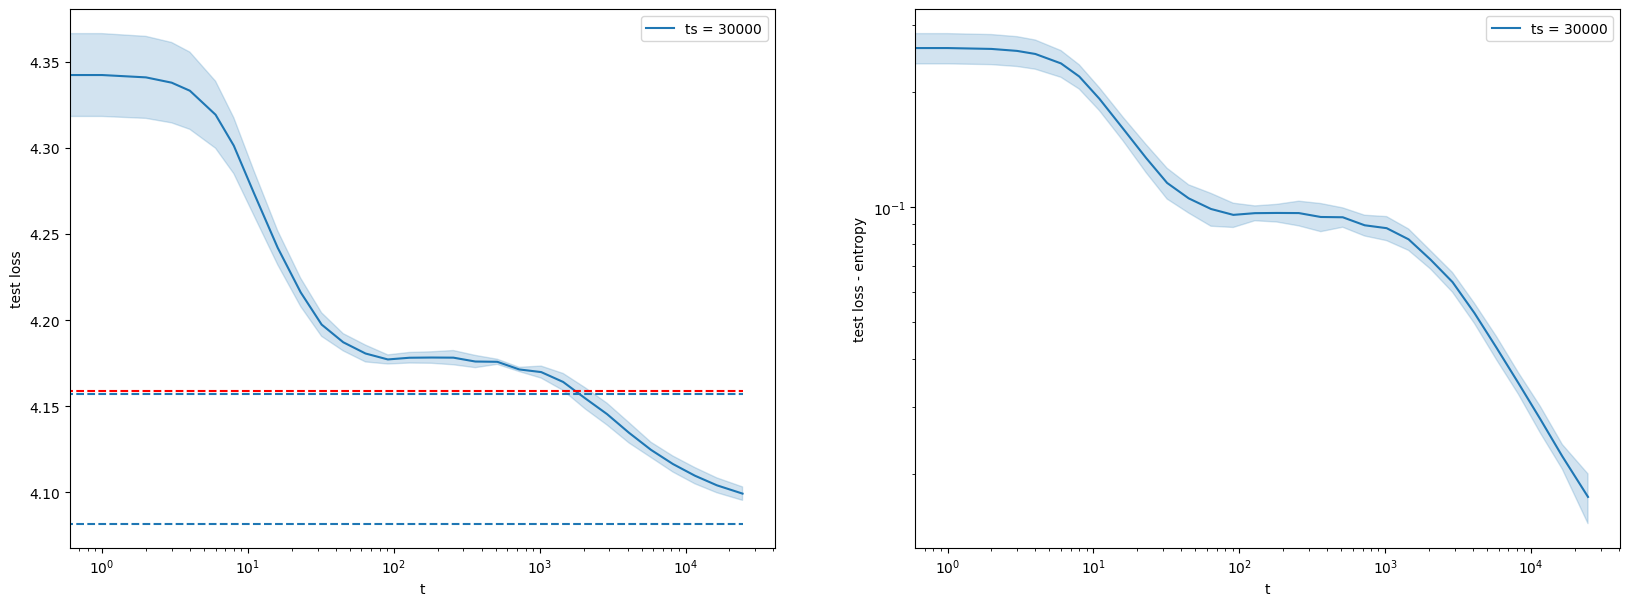

In [103]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 7 

Parametros

Pasos 

Vocab

Beta 

In [104]:
path = 'experimentos_resultados/fixed/beta_v/1.1_v16_30000_32_'

nexp = 8

t_step = 30000


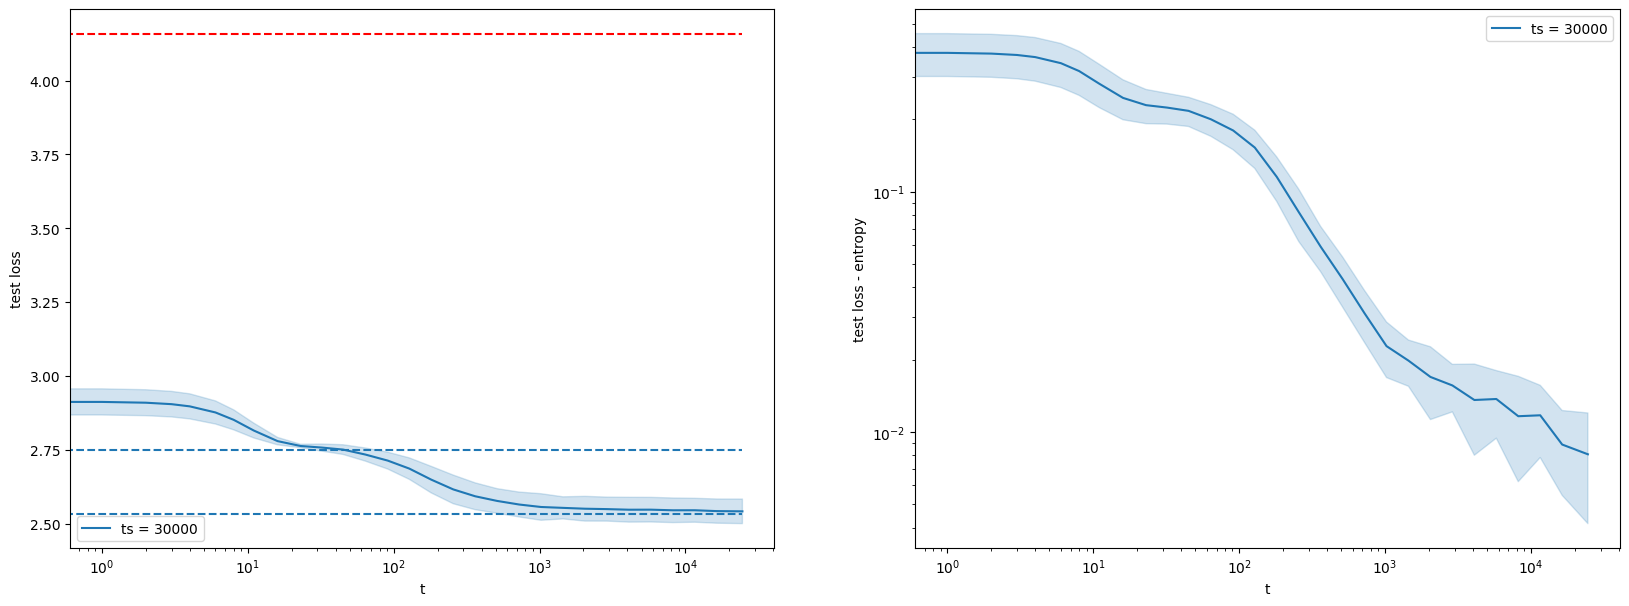

In [105]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 8 

Parametros

Pasos 

Vocab

Beta 

In [106]:
path = 'experimentos_resultados/fixed/beta_v/1.1_v32_30000_32_'

nexp = 8

t_step = 30000


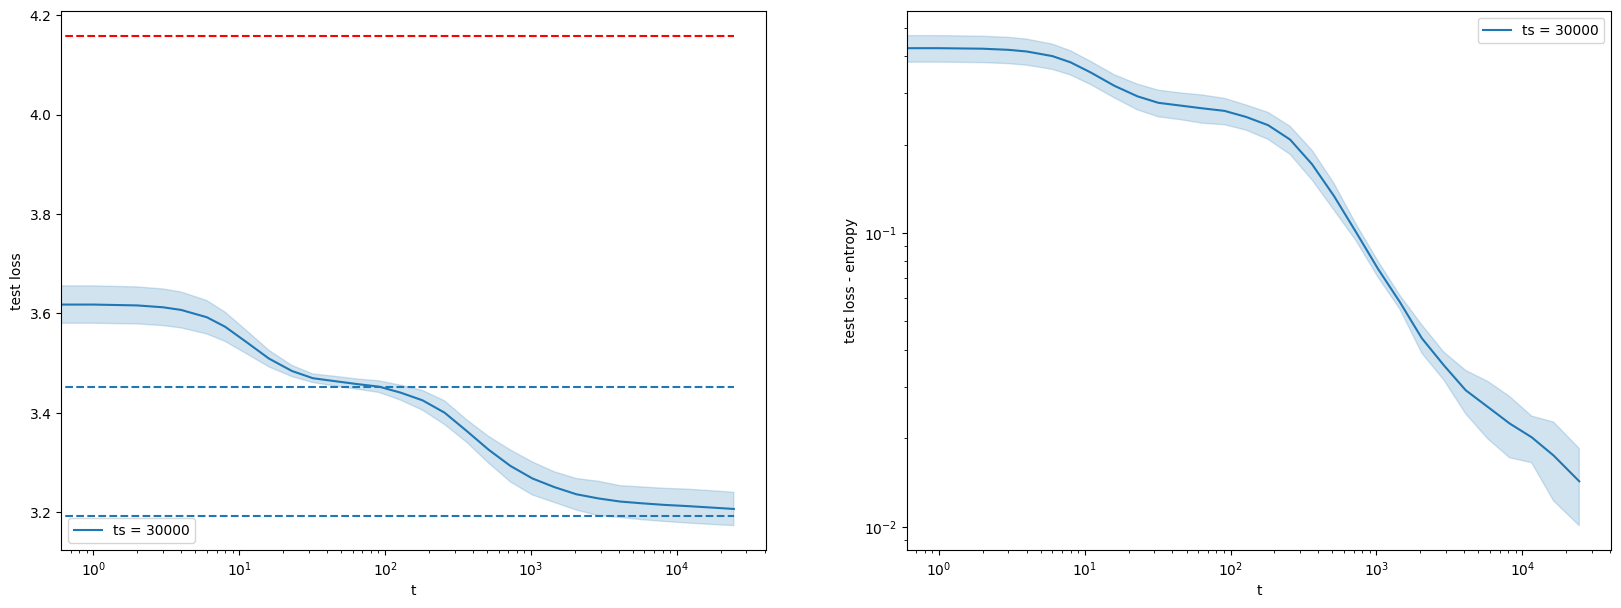

In [107]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

## Prueba 9 

Parametros

Pasos 

Vocab

Beta 

In [114]:
path = 'experimentos_resultados/fixed/beta_v/1.4_v16_30000_32_'

nexp = 8

t_step = 30000


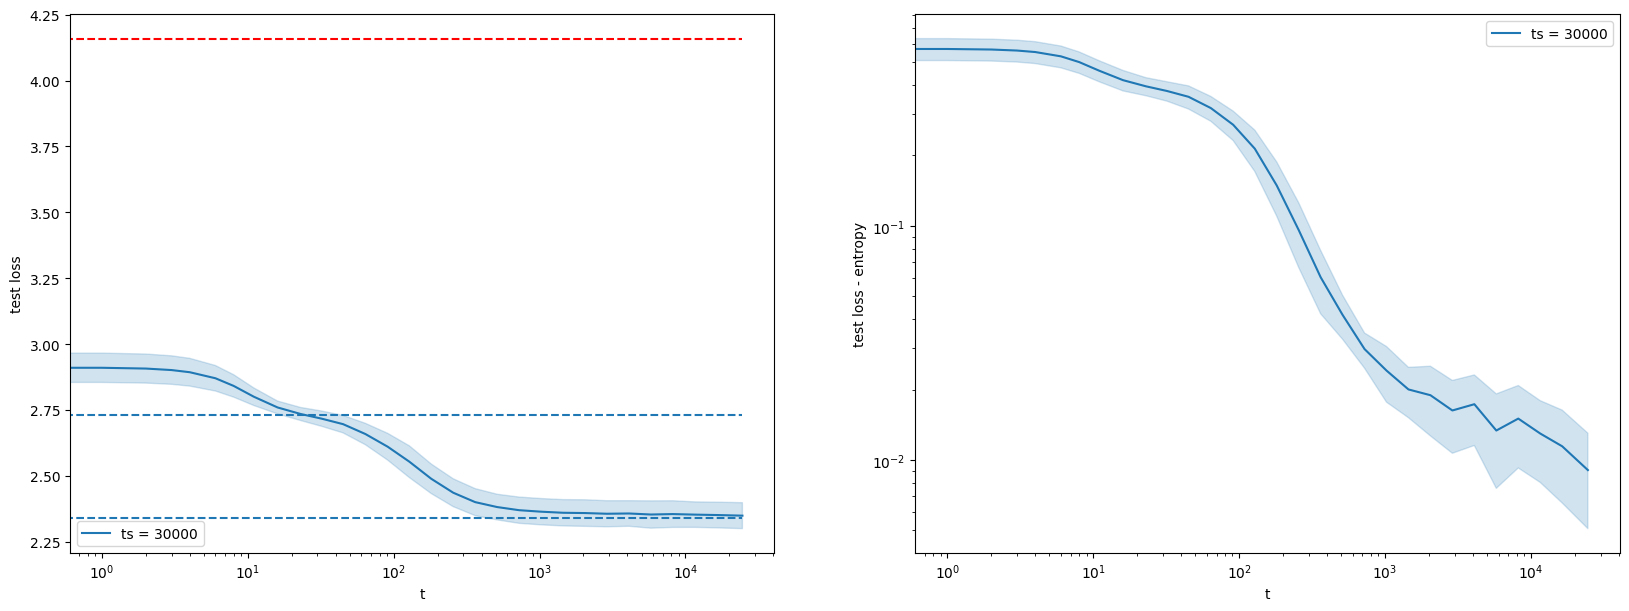

In [115]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [116]:
path = 'experimentos_resultados/fixed/beta_v/1.4_v32_30000_32_'

nexp = 8

t_step = 30000


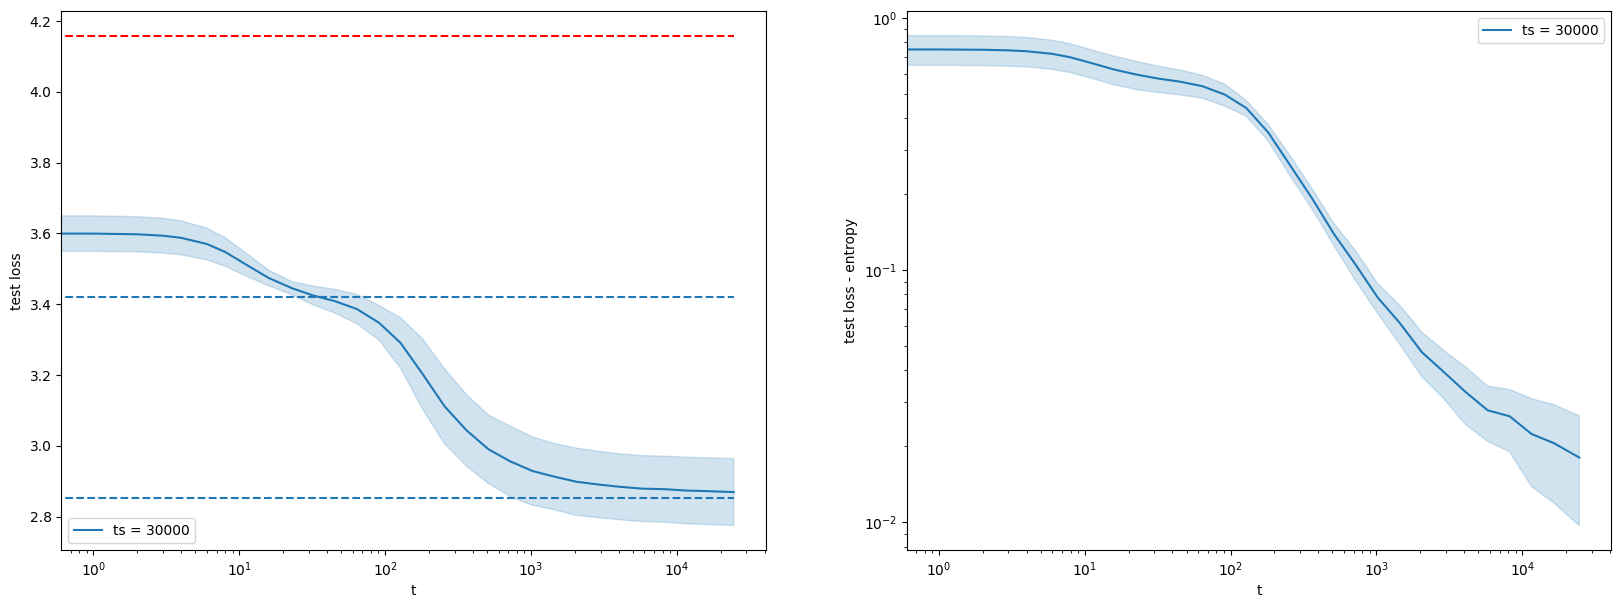

In [117]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [118]:
path = 'experimentos_resultados/fixed/beta_v/1.4_v64_30000_32_'

nexp = 8

t_step = 30000


FileNotFoundError: [Errno 2] No such file or directory: 'experimentos_resultados/fixed/beta_v/1.4_v64_30000_32_1.pt'

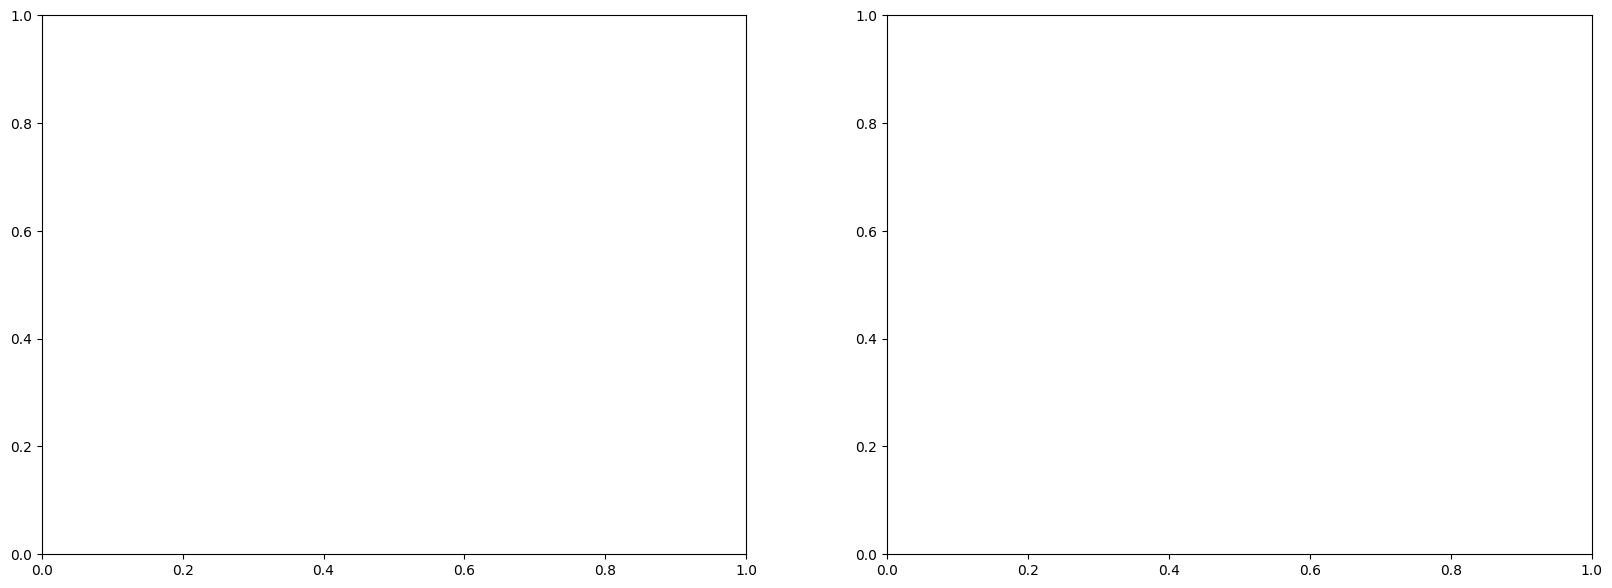

In [119]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [120]:
path = 'experimentos_resultados/fixed/beta_v/1.7_v16_30000_32_'

nexp = 8

t_step = 30000


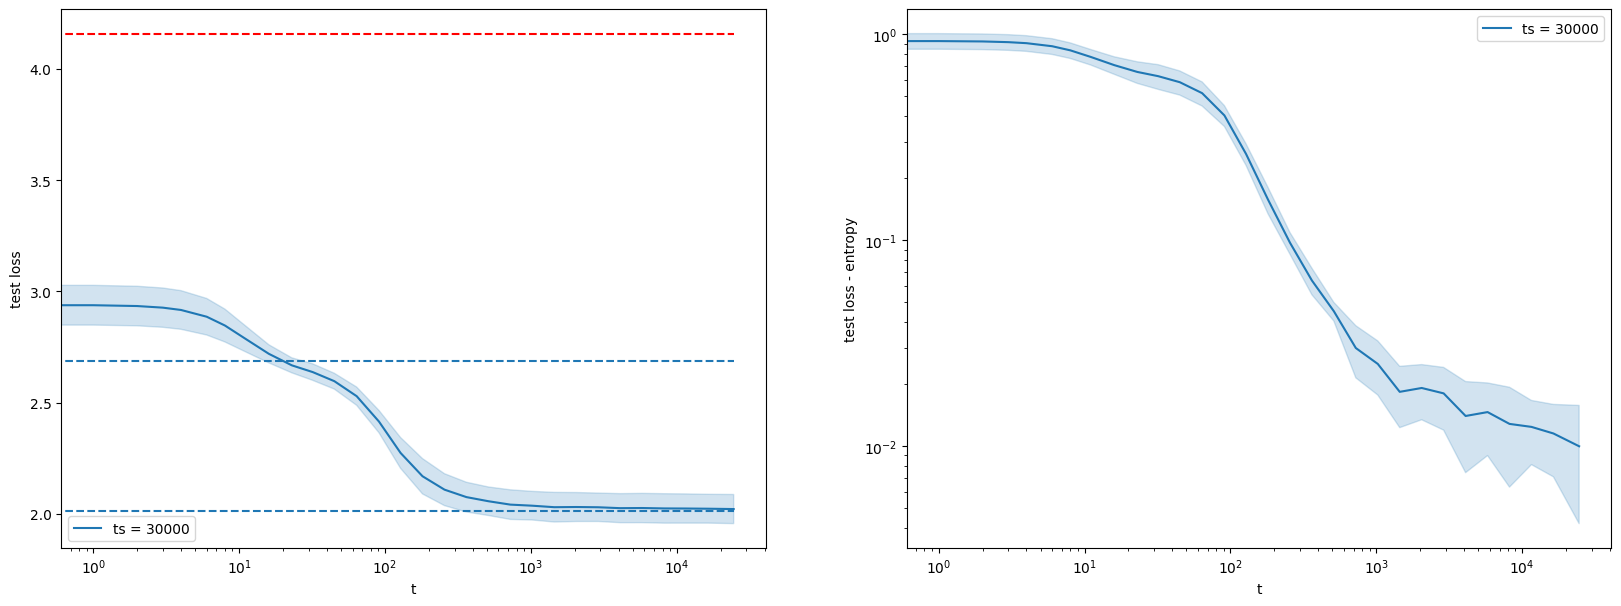

In [121]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [122]:
path = 'experimentos_resultados/fixed/beta_v/1.7_v32_30000_32_'

nexp = 8

t_step = 30000


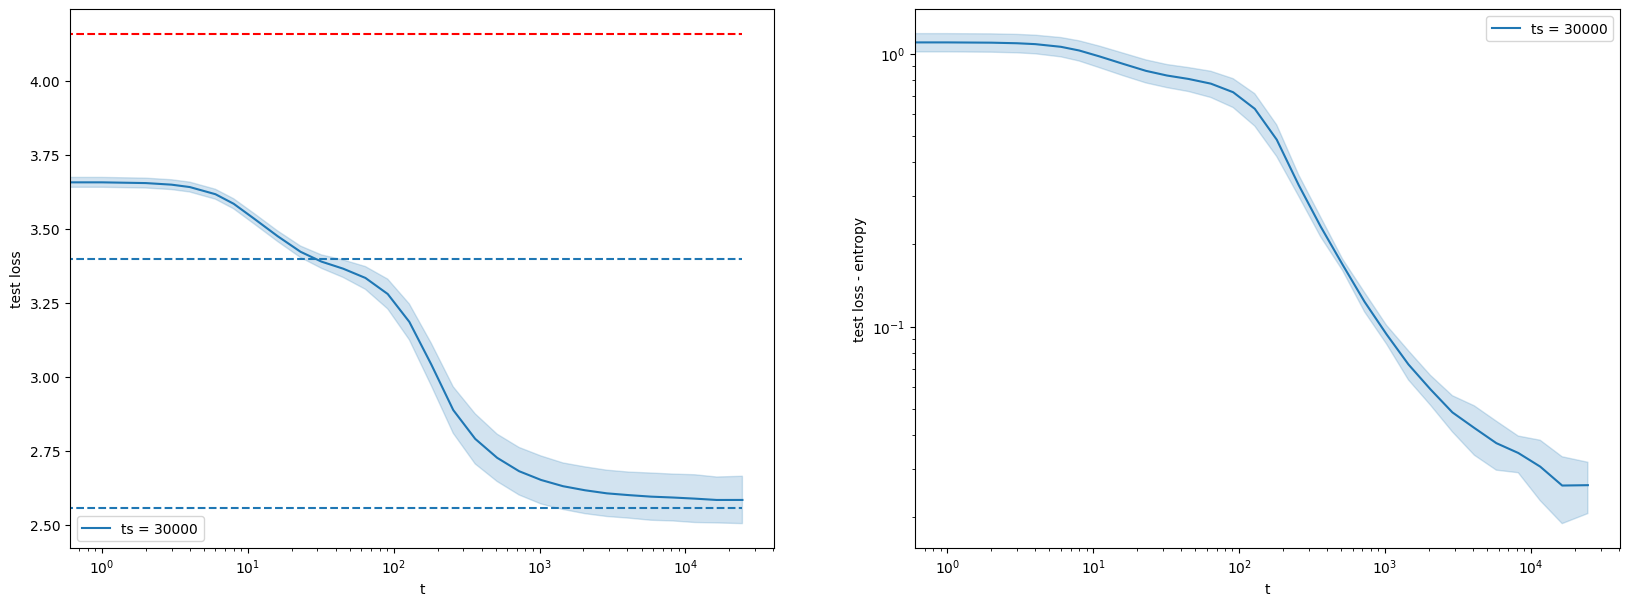

In [123]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [ ]:
path = 'experimentos_resultados/fixed/beta_v/0.8_v64_30000_32_'

nexp = 8

t_step = 30000


In [ ]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [ ]:
path = 'experimentos_resultados/fixed/beta_v/0.8_v64_30000_32_'

nexp = 8

t_step = 30000


In [ ]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()

In [ ]:
path = 'experimentos_resultados/fixed/beta_v/0.8_v64_30000_32_'

nexp = 8

t_step = 30000


In [ ]:
# Figura con dos paneles:
# izquierda: test loss promedio con banda ±σ y entropía promedio en línea punteada
# derecha: (test loss − entropy) promedio con banda ±σ
fig, ax = plt.subplots(1, 2, figsize=(20,7))

# Acumuladores por run
t_list = []      # tiempos por run (vector)
tl_list = []     # test loss por run (vector)
ent_list = []    # entropía por run (vector, replicado si originalmente es escalar)
marg_list = []
diff_list = []   # (test loss − entropy) por run (vector)
triv_entropy = []

# Recorremos runs 1..nexp
for i in range(1, nexp+1):
    # Carga de cada repetición
    # Nota: si tus .pt requieren modo "seguro", puedes usar add_safe_globals con argparse.Namespace
    res = torch.load(path + f'{i}.pt', map_location='cpu', weights_only=False)

    # Extraemos las series del dict
    dyn = res['output']['dynamics']     # lista de dicts por paso temporal
    ent = res['output']['entropy']      # escalar o serie
    marg = res['output']['marginal']    # escalar o serie

    # Convertimos a arrays NumPy para promediar
    t = np.asarray([d['t'] for d in dyn], dtype=float)
    tl = np.asarray([d['testloss'] for d in dyn], dtype=float)
    entr = np.asarray([math.log(64) for d in dyn], dtype=float)

    # Si la entropía es escalar, la replicamos al largo de t; si es serie, la recortamos
    if np.ndim(ent) == 0:
        ent_vec = np.full_like(t, float(ent))
    else:
        ent_vec = np.asarray(ent, dtype=float)[:len(t)]
    
    if np.ndim(marg) == 0:
        marg_vec = np.full_like(t, float(marg))
    else:
        marg_vec = np.asarray(marg, dtype=float)[:len(t)]

    # Guardamos cada run
    t_list.append(t)
    tl_list.append(tl)
    ent_list.append(ent_vec)
    marg_list.append(marg_vec)
    diff_list.append(tl - ent_vec)
    triv_entropy.append(entr)


# Alineamos longitudes: recortamos todas las series a la mínima longitud común L
L = min(len(x) for x in t_list)
T   = np.stack([x[:L] for x in t_list], axis=0)   # shape: [n_runs, L]
TL  = np.stack([x[:L] for x in tl_list], axis=0)  # shape: [n_runs, L]
ENT = np.stack([x[:L] for x in ent_list], axis=0) # shape: [n_runs, L]
MARG = np.stack([x[:L] for x in marg_list], axis=0) # shape: [n_runs, L]
DI  = np.stack([x[:L] for x in diff_list], axis=0)# shape: [n_runs, L]
triv_ENT = np.stack([x[:L] for x in triv_entropy], axis=0)# shape: [n_runs, L]

# Estadísticos por paso temporal (promedio y desviación estándar)
t_mean  = T.mean(axis=0)      # tiempo promedio (por si hay pequeñas diferencias entre runs)
tl_mean = TL.mean(axis=0)     # test loss promedio
tl_std  = TL.std(axis=0)      # σ de test loss
ent_mean = ENT.mean(axis=0)   # entropía promedio
marg_mean = MARG.mean(axis=0) # marginal promedio
di_mean = DI.mean(axis=0)     # (test loss − entropy) promedio
di_std  = DI.std(axis=0)      # σ de (test loss − entropy)
triv_ENT = triv_ENT.mean(axis=0)

# Color consistente por ts
c = f'C{t_step}'

# Panel izquierdo: test loss ±σ y entropía promedio (línea punteada)
ax[0].plot(t_mean, tl_mean, c, label=f'ts = {t_step}')
ax[0].plot()
ax[0].fill_between(t_mean, tl_mean - tl_std, tl_mean + tl_std, alpha=0.2, color=c)
ax[0].plot(t_mean, ent_mean, c, linestyle='dashed')
ax[0].plot(t_mean, marg_mean, c, linestyle='dashed')
ax[0].plot(t_mean, triv_ENT, 'red', linestyle='dashed')

# Panel derecho: (test loss − entropy) ±σ
ax[1].plot(t_mean, di_mean, c, label=f'ts = {t_step}')
ax[1].fill_between(t_mean, di_mean - di_std, di_mean + di_std, alpha=0.2, color=c)

# Formato y leyendas
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[0].set_xlabel('t')
ax[1].set_xlabel('t')
ax[0].set_ylabel('test loss')
ax[1].set_ylabel('test loss - entropy')
ax[0].legend()
ax[1].legend()